In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import glob
import polars as pl
import matplotlib.ticker as mticker

### Lectura de datos

In [2]:
# realizamos la lectura de los data set usando glob para leer todos los archivos csv que se encuentran en la carpeta data

DataAdmision = pd.read_csv("dataAdmision.csv", sep=",", encoding="latin-1")
DataMatricula = pd.read_csv("dataMatricula.csv", sep=",", encoding="UTF-8")

/var/folders/0g/z99vwkvx4td4drvln8fdl07r0000gn/T/ipykernel_38769/3360510909.py:3: DtypeWarning: Columns (1,4,8,12,16,20,24,28,32,36,40,42,83,84,125,127,128,130,132,134,136,138,140,142,144,146,148,169,192,195,198,201,204,207,210,213,216,219,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  DataAdmision = pd.read_csv("dataAdmision.csv", sep=",", encoding="latin-1")


KeyboardInterrupt: 

In [ ]:
#Leemos las columnas de cada data set para conocer su estructura y poder realizar un análisis exploratorio de los datos 
print("Columnas del data set de admision:")
print(DataAdmision.columns)
print(DataAdmision.shape[0])
# Queremos filtrar hasta la columna 20 del dataframe de admision para quedarnos solo con las columnas que nos interesan para el análisis exploratorio de los datos, ya que las columnas posteriores no aportan información relevante para nuestro análisis.
# DataAdmision = DataAdmision.iloc[:, :20]
 # Comentado para permitir EDA completo
print("Columnas del data set de matricula:")
print(DataMatricula.columns)
print(DataMatricula.shape[0])

Columnas del data set de admision:
Index(['ID_aux', 'SIT_POSTULANTE', 'COD_CARRERA_PREF_01', 'ESTADO_PREF_01',
       'PTJE_PREF01', 'POND_ACAD_PREF01', 'COD_CARRERA_PREF_02',
       'ESTADO_PREF_02', 'PTJE_PREF02', 'POND_ACAD_PREF02',
       ...
       'ESTADO_PREF_19_PACE', 'PTJE_PREF_19_PACE', 'COD_CARRERA_PREF_20_PACE',
       'ESTADO_PREF_20_PACE', 'PTJE_PREF_20_PACE', 'ORDEN_PREF',
       'COD_CARRERA_PREF', 'ESTADO_PREF', 'TIPO_PREF', 'PTJE_PREF'],
      dtype='object', length=285)
2655680
Columnas del data set de matricula:
Index(['AÑO', 'TOTAL MATRÍCULA', 'TOTAL MATRÍCULA MUJERES',
       'TOTAL MATRÍCULA HOMBRES', 'TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS',
       'TOTAL MATRÍCULA PRIMER AÑO', 'TOTAL MATRÍCULA MUJERES PRIMER AÑO',
       'TOTAL MATRÍCULA HOMBRES PRIMER AÑO',
       'TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS PRIMER AÑO',
       'CLASIFICACIÓN INSTITUCIÓN NIVEL 1',
       'CLASIFICACIÓN INSTITUCIÓN NIVEL 2',
       'CLASIFICACIÓN INSTITUCIÓN NIVEL 3', 'CÓDIGO 

---
# 📊 Análisis Exploratorio de Datos — Admisión

## 1. Carga e Inspección Inicial

In [ ]:
# Carga del dataset
# df = pd.read_csv('dataMatricula.csv', low_memory=False)
 # (Dataset ya cargado al principio)

# Eliminar filas completamente vacías (la última fila del CSV está en blanco)
DataMatricula.dropna(how='all', inplace=True)

print(f'Dimensiones del dataset: {DataMatricula.shape[0]:,} filas × {DataMatricula.shape[1]} columnas')

Dimensiones del dataset: 106,887 filas × 59 columnas


In [ ]:
# Vista rápida de las primeras filas
DataMatricula.head(3)

,AÑO,TOTAL MATRÍCULA,TOTAL MATRÍCULA MUJERES,TOTAL MATRÍCULA HOMBRES,TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS,TOTAL MATRÍCULA PRIMER AÑO,TOTAL MATRÍCULA MUJERES PRIMER AÑO,TOTAL MATRÍCULA HOMBRES PRIMER AÑO,TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS PRIMER AÑO,CLASIFICACIÓN INSTITUCIÓN NIVEL 1,...,TES PARTICULAR SUBVENCIONADO,TES PARTICULAR PAGADO,TES CORP. DE ADMINISTRACIÓN DELEGADA,TES SERVICIO LOCAL EDUCACION,TOTAL TES,% COBERTURA TES,TIPO ESTABLECIMIENTO HC,TIPO ESTABLECIMIENTO TP,CLAS_EST ADULTO,CLAS_EST JOVEN
0,MAT_2024,1,NaN,1.0,NaN,NaN,NaN,NaN,NaN,Institutos Profesionales,...,NaN,1.0,NaN,NaN,1,"100,00%",1.0,NaN,NaN,1.0
1,MAT_2024,22,9.0,13.0,NaN,NaN,NaN,NaN,NaN,Institutos Profesionales,...,8.0,3.0,NaN,NaN,21,"95,50%",11.0,10.0,1.0,20.0
2,MAT_2024,16,5.0,11.0,NaN,NaN,NaN,NaN,NaN,Institutos Profesionales,...,7.0,1.0,1.0,NaN,15,"93,80%",7.0,8.0,NaN,15.0


In [ ]:
# Tipos de datos y conteo de no-nulos
DataMatricula.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106887 entries, 0 to 106886
Data columns (total 59 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   AÑO                                                   106887 non-null  object 
 1   TOTAL MATRÍCULA                                       106887 non-null  int64  
 2   TOTAL MATRÍCULA MUJERES                               98593 non-null   float64
 3   TOTAL MATRÍCULA HOMBRES                               98205 non-null   float64
 4   TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS             16 non-null      float64
 5   TOTAL MATRÍCULA PRIMER AÑO                            70322 non-null   float64
 6   TOTAL MATRÍCULA MUJERES PRIMER AÑO                    65583 non-null   float64
 7   TOTAL MATRÍCULA HOMBRES PRIMER AÑO                    64842 non-null   float64
 8   TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS PR

In [ ]:
# Estadísticas descriptivas de las columnas numéricas
DataMatricula.describe()

,TOTAL MATRÍCULA,TOTAL MATRÍCULA MUJERES,TOTAL MATRÍCULA HOMBRES,TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS,TOTAL MATRÍCULA PRIMER AÑO,TOTAL MATRÍCULA MUJERES PRIMER AÑO,TOTAL MATRÍCULA HOMBRES PRIMER AÑO,TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS PRIMER AÑO,CÓDIGO DE INSTITUCIÓN,DURACIÓN ESTUDIO CARRERA,...,TES MUNICIPAL,TES PARTICULAR SUBVENCIONADO,TES PARTICULAR PAGADO,TES CORP. DE ADMINISTRACIÓN DELEGADA,TES SERVICIO LOCAL EDUCACION,TOTAL TES,TIPO ESTABLECIMIENTO HC,TIPO ESTABLECIMIENTO TP,CLAS_EST ADULTO,CLAS_EST JOVEN
count,106887.000000,98593.000000,98205.000000,16.0,70322.000000,65583.000000,64842.000000,6.0,106887.000000,106887.000000,...,94587.000000,98341.000000,61458.000000,52228.000000,15971.000000,106887.000000,101514.000000,88416.000000,73163.000000,103371.000000
mean,84.931844,49.228627,43.017117,1.0,36.331219,20.758992,18.405370,1.0,133.568320,6.101182,...,25.987271,43.108083,16.287042,5.579230,4.267610,75.386801,58.328575,24.166463,10.255102,70.692699
std,152.650171,93.871870,87.214156,0.0,46.210945,29.710141,27.927831,0.0,150.840332,2.743224,...,40.838689,74.307838,77.920860,7.939722,6.944336,141.417714,125.895955,37.204575,15.052939,137.223844
min,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,12.000000,5.000000,5.000000,1.0,12.000000,4.000000,4.000000,1.0,54.000000,4.000000,...,4.000000,5.000000,1.000000,1.000000,1.000000,8.000000,7.000000,4.000000,2.000000,8.000000
50%,37.000000,16.000000,17.000000,1.0,25.000000,12.000000,11.000000,1.0,90.000000,5.000000,...,12.000000,16.000000,3.000000,3.000000,2.000000,29.000000,20.000000,12.000000,6.000000,26.000000
75%,96.000000,52.000000,46.000000,1.0,45.000000,26.000000,23.000000,1.0,143.000000,8.000000,...,32.000000,47.000000,9.000000,7.000000,4.000000,83.000000,54.000000,31.000000,13.000000,73.000000
max,4873.000000,3170.000000,3594.000000,1.0,1283.000000,811.000000,1127.000000,1.0,959.000000,24.000000,...,1377.000000,1150.000000,3788.000000,229.000000,107.000000,4833.000000,4803.000000,1611.000000,416.000000,4830.000000


### 🔎 Hallazgo 1 — Estructura general
> El dataset contiene **~106.888 registros** (uno por carrera-sede-año-jornada) y **51 columnas** que cubren información institucional, geográfica, demográfica (género, edad) y de origen escolar de los matriculados. El campo `AÑO` viene en formato `MAT_YYYY`, no como entero, lo que se corregirá en la etapa de limpieza.

## 2. Análisis de Valores Nulos y Duplicados

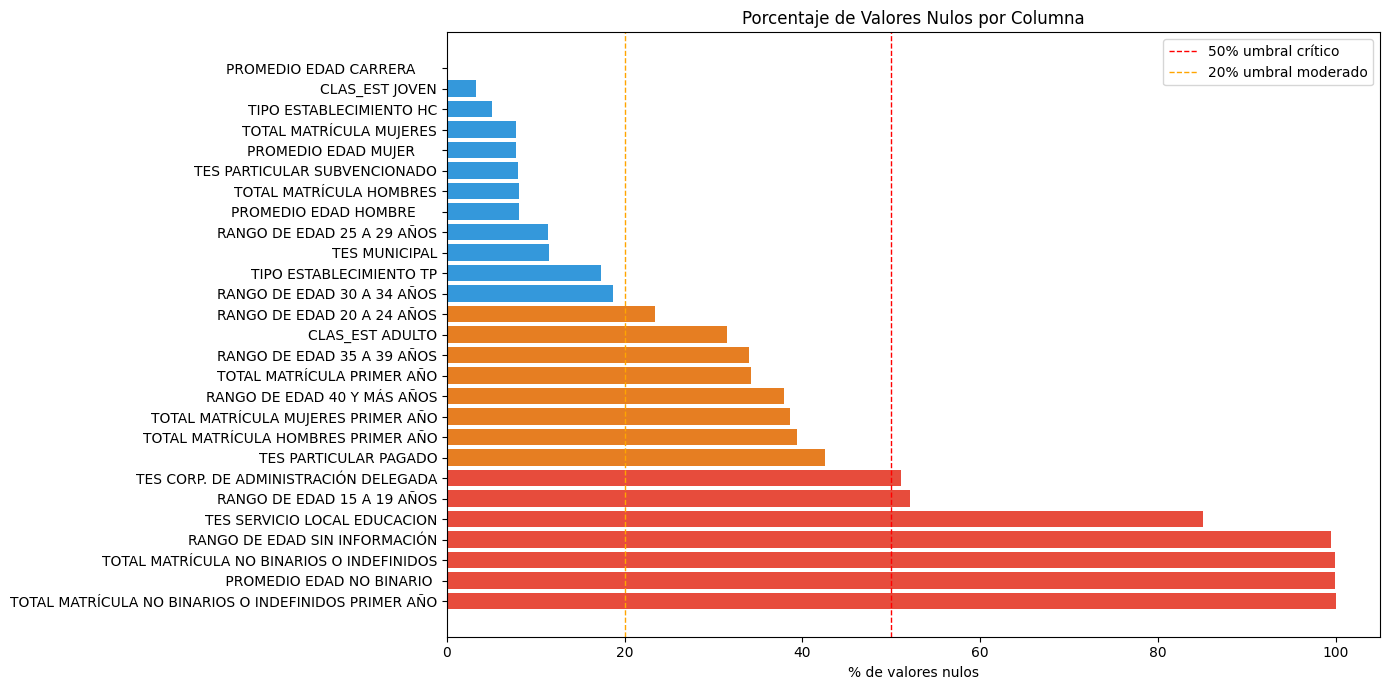

                                             Columna   % Nulos
TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS PRIMER AÑO 99.994387
                           PROMEDIO EDAD NO BINARIO  99.985031
           TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS 99.985031
                       RANGO DE EDAD SIN INFORMACIÓN 99.436788
                        TES SERVICIO LOCAL EDUCACION 85.058052
                          RANGO DE EDAD 15 A 19 AÑOS 52.140111
                TES CORP. DE ADMINISTRACIÓN DELEGADA 51.137182
                               TES PARTICULAR PAGADO 42.501895
                  TOTAL MATRÍCULA HOMBRES PRIMER AÑO 39.335934
                  TOTAL MATRÍCULA MUJERES PRIMER AÑO 38.642679
                         RANGO DE EDAD 40 Y MÁS AÑOS 37.883933
                          TOTAL MATRÍCULA PRIMER AÑO 34.209024
                          RANGO DE EDAD 35 A 39 AÑOS 33.967648
                                     CLAS_EST ADULTO 31.551077
                          RANGO DE EDAD 20 A 24 AÑOS 23

In [ ]:
# Porcentaje de nulos por columna
nulos = (DataMatricula.isnull().sum() / len(DataMatricula) * 100).sort_values(ascending=False)
nulos_df = nulos[nulos > 0].reset_index()
nulos_df.columns = ['Columna', '% Nulos']

# Gráfico
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#e74c3c' if v > 50 else '#e67e22' if v > 20 else '#3498db' for v in nulos_df['% Nulos']]
ax.barh(nulos_df['Columna'], nulos_df['% Nulos'], color=colors)
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% umbral crítico')
ax.axvline(20, color='orange', linestyle='--', linewidth=1, label='20% umbral moderado')
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de Valores Nulos por Columna')
ax.legend()
plt.tight_layout()
plt.savefig('nulos_por_columna.png', dpi=150)
plt.show()

print(nulos_df.to_string(index=False))

In [ ]:
# Duplicados exactos
n_duplicados = DataMatricula.duplicated().sum()
print(f'Filas duplicadas exactas: {n_duplicados}')

# Verificar unicidad del identificador natural: AÑO + CÓDIGO CARRERA
dup_clave = DataMatricula.duplicated(subset=['AÑO', 'CÓDIGO CARRERA']).sum()
print(f'Duplicados por clave (AÑO + CÓDIGO CARRERA): {dup_clave}')
print('→ Nota: duplicados en clave natural son esperados si una carrera tiene múltiples jornadas.')

Filas duplicadas exactas: 0
Duplicados por clave (AÑO + CÓDIGO CARRERA): 0
→ Nota: duplicados en clave natural son esperados si una carrera tiene múltiples jornadas.


### 🔎 Hallazgo 2 — Valores nulos
> Varias columnas presentan altos porcentajes de nulos. Esto obedece a dos causas principales:
> - **Columnas de género no binario** (`TOTAL MATRÍCULA NO BINARIOS...`): estas categorías existen solo desde años recientes, por lo que la mayoría de los registros anteriores son nulos.
> - **Columnas de rango de edad específico**: no todos los registros tienen desagregación por edad (especialmente en registros con muy pocos alumnos).
> - **`% COBERTURA TES` y columnas TES**: requieren que el alumno tenga registro de egreso escolar; en algunos casos no hay datos disponibles.
>
> Las columnas con >50% de nulos deben usarse con precaución o ser descartadas en modelos predictivos.

## 3. Exploración Univariada — Variables Clave

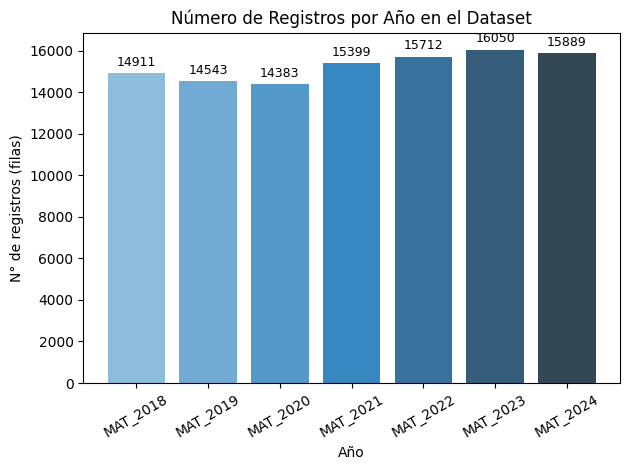

AÑO
MAT_2018    14911
MAT_2019    14543
MAT_2020    14383
MAT_2021    15399
MAT_2022    15712
MAT_2023    16050
MAT_2024    15889
Name: count, dtype: int64


In [ ]:
# ── Distribución de registros por AÑO ──
conteo_anio = DataMatricula['AÑO'].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(conteo_anio.index, conteo_anio.values, color=sns.color_palette('Blues_d', len(conteo_anio)))
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_title('Número de Registros por Año en el Dataset')
ax.set_xlabel('Año')
ax.set_ylabel('N° de registros (filas)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('registros_por_anio.png', dpi=150)
plt.show()

print(conteo_anio)

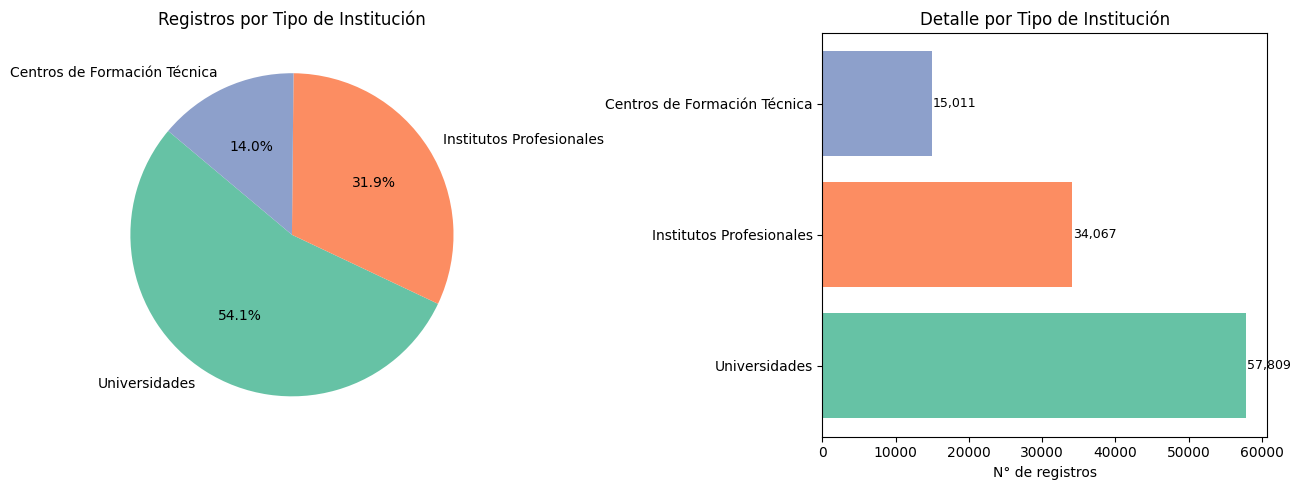

In [ ]:
# ── Distribución de registros por tipo de institución ──
tipo_inst = DataMatricula['CLASIFICACIÓN INSTITUCIÓN NIVEL 1'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].pie(tipo_inst.values, labels=tipo_inst.index, autopct='%1.1f%%',
          colors=sns.color_palette('Set2', len(tipo_inst)), startangle=140)
ax[0].set_title('Registros por Tipo de Institución')

ax[1].barh(tipo_inst.index, tipo_inst.values, color=sns.color_palette('Set2', len(tipo_inst)))
ax[1].set_xlabel('N° de registros')
ax[1].set_title('Detalle por Tipo de Institución')
for i, v in enumerate(tipo_inst.values):
    ax[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('tipo_institucion.png', dpi=150)
plt.show()

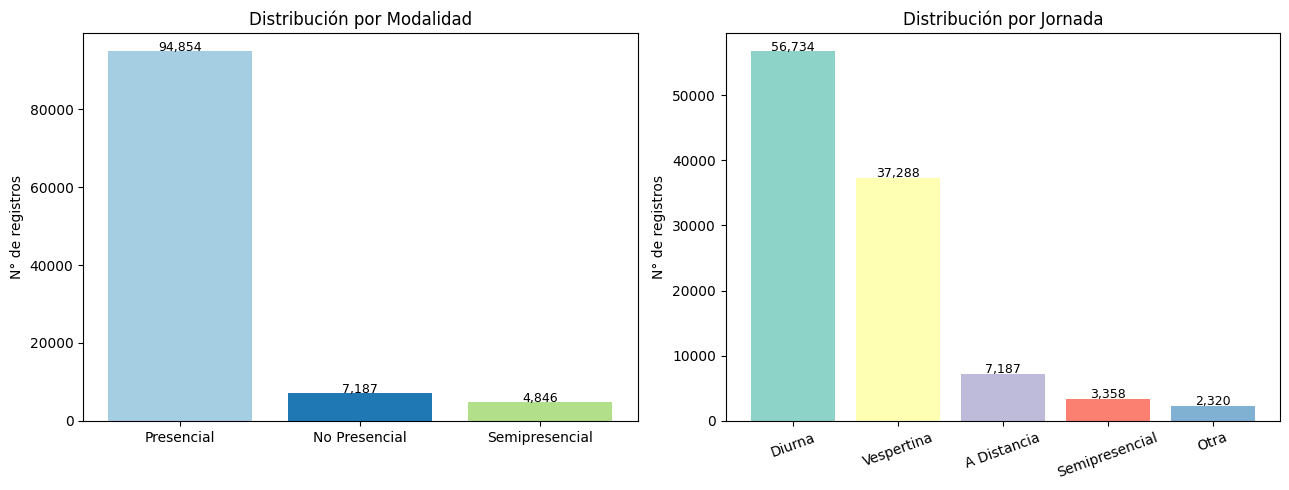

In [ ]:
# ── Distribución por modalidad y jornada ──
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

modalidad = DataMatricula['MODALIDAD'].value_counts()
ax[0].bar(modalidad.index, modalidad.values, color=sns.color_palette('Paired', len(modalidad)))
ax[0].set_title('Distribución por Modalidad')
ax[0].set_ylabel('N° de registros')
for i, v in enumerate(modalidad.values):
    ax[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

jornada = DataMatricula['JORNADA'].value_counts()
ax[1].bar(jornada.index, jornada.values, color=sns.color_palette('Set3', len(jornada)))
ax[1].set_title('Distribución por Jornada')
ax[1].set_ylabel('N° de registros')
plt.xticks(rotation=20)
for i, v in enumerate(jornada.values):
    ax[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('modalidad_jornada.png', dpi=150)
plt.show()

### 🔎 Hallazgo 3 — Modalidad y Jornada
> La gran mayoría de los registros corresponden a modalidad **Presencial**, con la jornada **Vespertina** y **Diurna** siendo las más frecuentes. La modalidad **A Distancia** ha crecido notoriamente desde 2020, lo cual probablemente refleja el efecto de la pandemia COVID-19.

## 4. Exploración Temporal — Evolución 2018–2024

In [ ]:
# Convertir AÑO a entero para facilitar el análisis temporal
DataMatricula['AÑO_NUM'] = DataMatricula['AÑO'].str.extract(r'(\d{4})').astype(int)

# Limpiar columnas numéricas con separador decimal de coma
cols_numericas = ['TOTAL MATRÍCULA', 'TOTAL MATRÍCULA MUJERES', 'TOTAL MATRÍCULA HOMBRES',
                  'TOTAL MATRÍCULA PRIMER AÑO']

for col in cols_numericas:
    if DataMatricula[col].dtype == object:
        DataMatricula[col] = DataMatricula[col].str.replace(',', '.', regex=False)
    DataMatricula[col] = pd.to_numeric(DataMatricula[col], errors='coerce')

print('✅ Columnas numéricas convertidas.')

✅ Columnas numéricas convertidas.


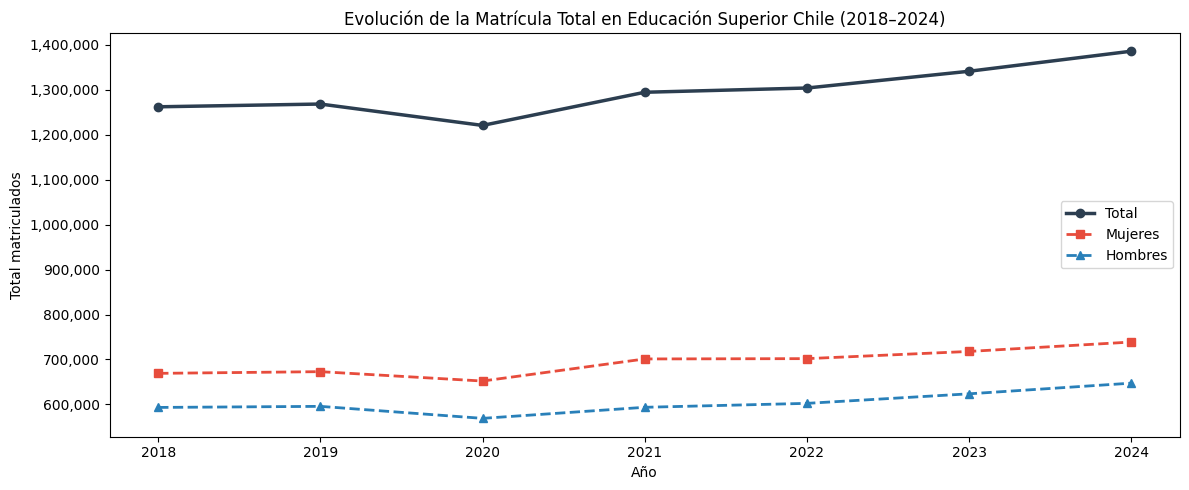

 AÑO_NUM  TOTAL MATRÍCULA  TOTAL MATRÍCULA MUJERES  TOTAL MATRÍCULA HOMBRES
    2018          1262334                 669094.0                 593240.0
    2019          1268483                 672846.0                 595637.0
    2020          1220898                 651985.0                 568913.0
    2021          1294701                 701154.0                 593547.0
    2022          1304147                 701837.0                 602310.0
    2023          1341448                 717883.0                 623563.0
    2024          1386099                 738799.0                 647286.0


In [ ]:
# ── Matrícula total por año ──
matricula_anio = DataMatricula.groupby('AÑO_NUM')[['TOTAL MATRÍCULA', 'TOTAL MATRÍCULA MUJERES',
                                         'TOTAL MATRÍCULA HOMBRES']].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(matricula_anio['AÑO_NUM'], matricula_anio['TOTAL MATRÍCULA'],
        marker='o', linewidth=2.5, label='Total', color='#2c3e50')
ax.plot(matricula_anio['AÑO_NUM'], matricula_anio['TOTAL MATRÍCULA MUJERES'],
        marker='s', linewidth=2, linestyle='--', label='Mujeres', color='#e74c3c')
ax.plot(matricula_anio['AÑO_NUM'], matricula_anio['TOTAL MATRÍCULA HOMBRES'],
        marker='^', linewidth=2, linestyle='--', label='Hombres', color='#2980b9')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Evolución de la Matrícula Total en Educación Superior Chile (2018–2024)')
ax.set_xlabel('Año')
ax.set_ylabel('Total matriculados')
ax.legend()
ax.set_xticks(matricula_anio['AÑO_NUM'])
plt.tight_layout()
plt.savefig('evolucion_matricula.png', dpi=150)
plt.show()

print(matricula_anio.to_string(index=False))

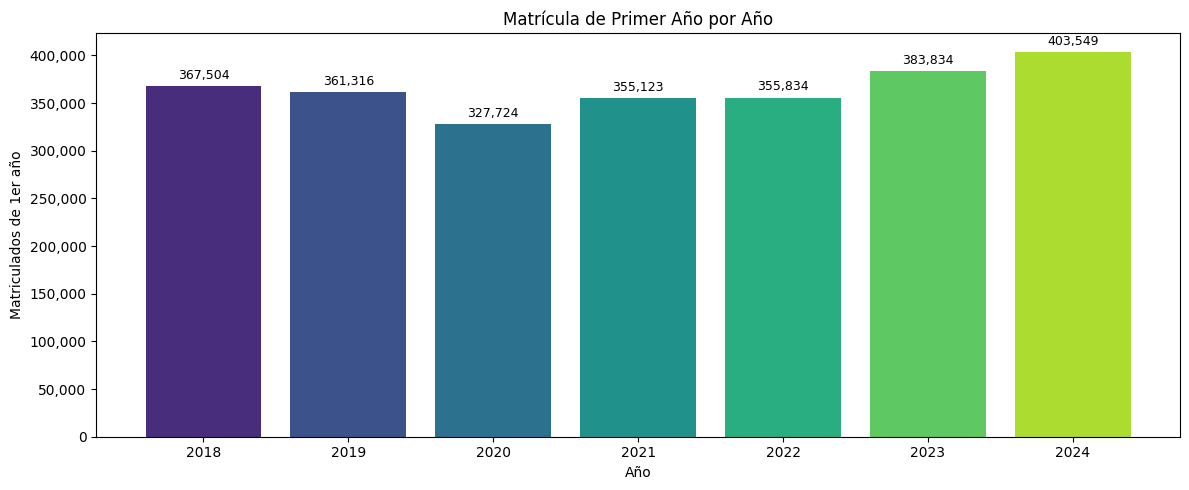

In [ ]:
# ── Matrícula de primer año por año ──
primer_anio = DataMatricula.groupby('AÑO_NUM')['TOTAL MATRÍCULA PRIMER AÑO'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(primer_anio['AÑO_NUM'], primer_anio['TOTAL MATRÍCULA PRIMER AÑO'],
              color=sns.color_palette('viridis', len(primer_anio)))
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Matrícula de Primer Año por Año')
ax.set_xlabel('Año')
ax.set_ylabel('Matriculados de 1er año')
plt.tight_layout()
plt.savefig('primer_anio.png', dpi=150)
plt.show()

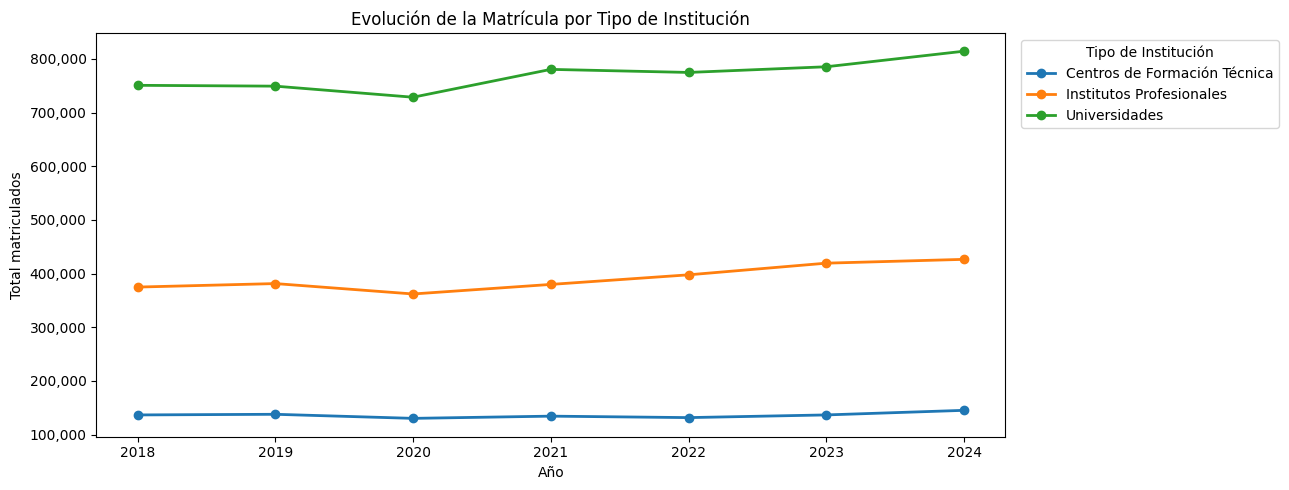

In [ ]:
# ── Evolución por tipo de institución ──
mat_inst_anio = DataMatricula.groupby(['AÑO_NUM', 'CLASIFICACIÓN INSTITUCIÓN NIVEL 1'])['TOTAL MATRÍCULA'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for tipo, group in mat_inst_anio.groupby('CLASIFICACIÓN INSTITUCIÓN NIVEL 1'):
    ax.plot(group['AÑO_NUM'], group['TOTAL MATRÍCULA'], marker='o', label=tipo, linewidth=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Evolución de la Matrícula por Tipo de Institución')
ax.set_xlabel('Año')
ax.set_ylabel('Total matriculados')
ax.legend(title='Tipo de Institución', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticks(mat_inst_anio['AÑO_NUM'].unique())
plt.tight_layout()
plt.savefig('matricula_por_tipo.png', dpi=150)
plt.show()

### 🔎 Hallazgo 4 — Tendencias temporales
> - La matrícula total muestra una **leve tendencia a la baja** entre 2018 y 2024, lo que es consistente con datos demográficos de menor natalidad y mayor selectividad.
> - Las **mujeres superan a los hombres** en matrícula total en todo el período, una tendencia que se ha consolidado en la última década.
> - Las **Universidades** concentran la mayor matrícula, seguidas por Institutos Profesionales (IP) y Centros de Formación Técnica (CFT).
> - La matrícula de **primer año** presenta cierta volatilidad, con una caída notable alrededor de 2020-2021 (efecto pandemia).

## 5. Exploración Geográfica — Distribución por Región

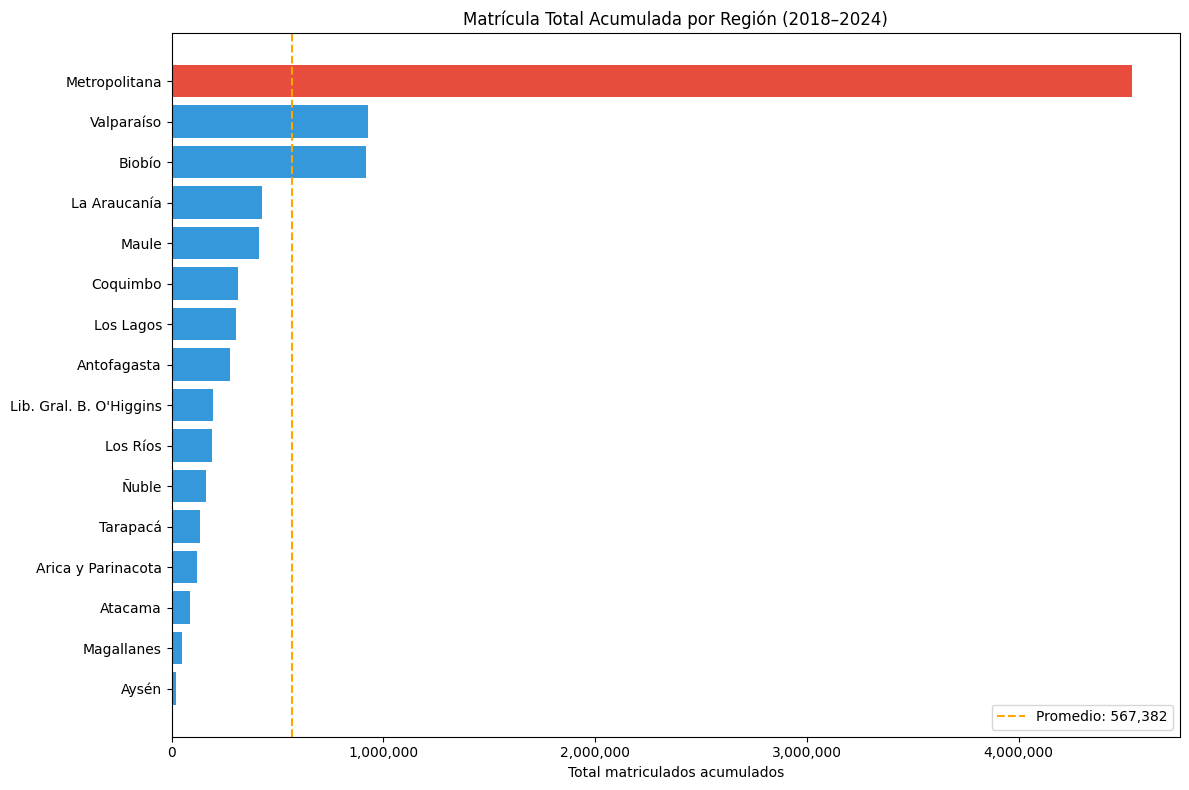

In [ ]:
# ── Matrícula total por región (promedio del período) ──
mat_region = DataMatricula.groupby('REGIÓN')['TOTAL MATRÍCULA'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if r == 'Metropolitana' else '#3498db' for r in mat_region.index]
ax.barh(mat_region.index, mat_region.values, color=colors)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Matrícula Total Acumulada por Región (2018–2024)')
ax.set_xlabel('Total matriculados acumulados')
ax.axvline(mat_region.mean(), color='orange', linestyle='--', label=f'Promedio: {mat_region.mean():,.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('matricula_por_region.png', dpi=150)
plt.show()

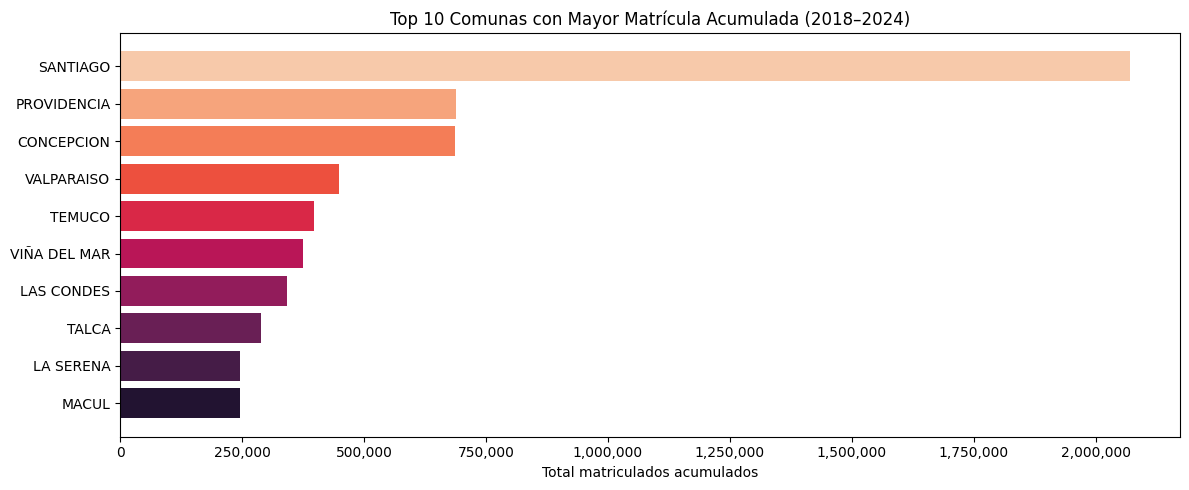

In [ ]:
# ── Top 10 comunas por matrícula ──
top_comunas = DataMatricula.groupby('COMUNA')['TOTAL MATRÍCULA'].sum().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_comunas.index, top_comunas.values, color=sns.color_palette('rocket', 10))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Top 10 Comunas con Mayor Matrícula Acumulada (2018–2024)')
ax.set_xlabel('Total matriculados acumulados')
plt.tight_layout()
plt.savefig('top_comunas.png', dpi=150)
plt.show()

### 🔎 Hallazgo 5 — Concentración geográfica
> Existe una **marcada concentración** de la matrícula en la Región Metropolitana, que supera ampliamente al resto de las regiones. Le siguen en volumen las regiones del Biobío, Valparaíso y La Araucanía. Las comunas de Santiago, Concepción y Valparaíso concentran la mayor cantidad de matrícula a nivel comunal. Esto es un factor importante a considerar al modelar determinantes del éxito: el acceso geográfico es una variable confusora relevante.

## 6. Exploración por Tipo de Institución y Acreditación

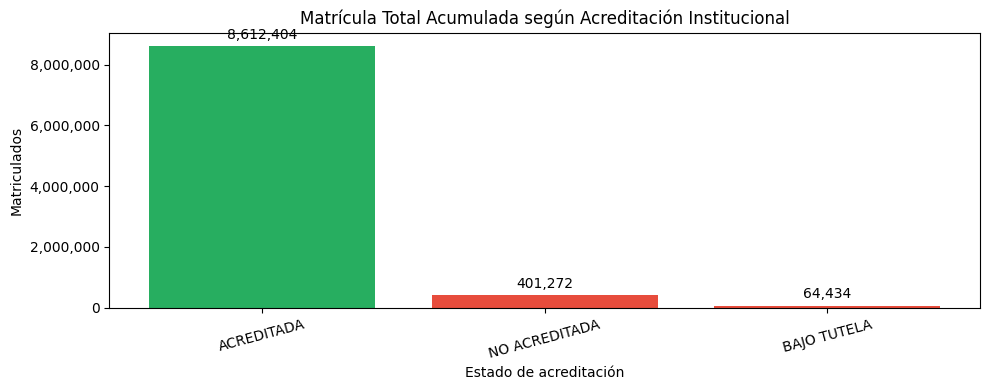

In [ ]:
# ── Acreditación institucional vs matrícula ──
mat_acred = DataMatricula.groupby(['ACREDITACIÓN INSTITUCIONAL'])['TOTAL MATRÍCULA'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(mat_acred.index, mat_acred.values,
              color=['#27ae60' if 'ACREDITADA' in v and 'NO' not in v else '#e74c3c' for v in mat_acred.index])
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Matrícula Total Acumulada según Acreditación Institucional')
ax.set_xlabel('Estado de acreditación')
ax.set_ylabel('Matriculados')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('acreditacion.png', dpi=150)
plt.show()

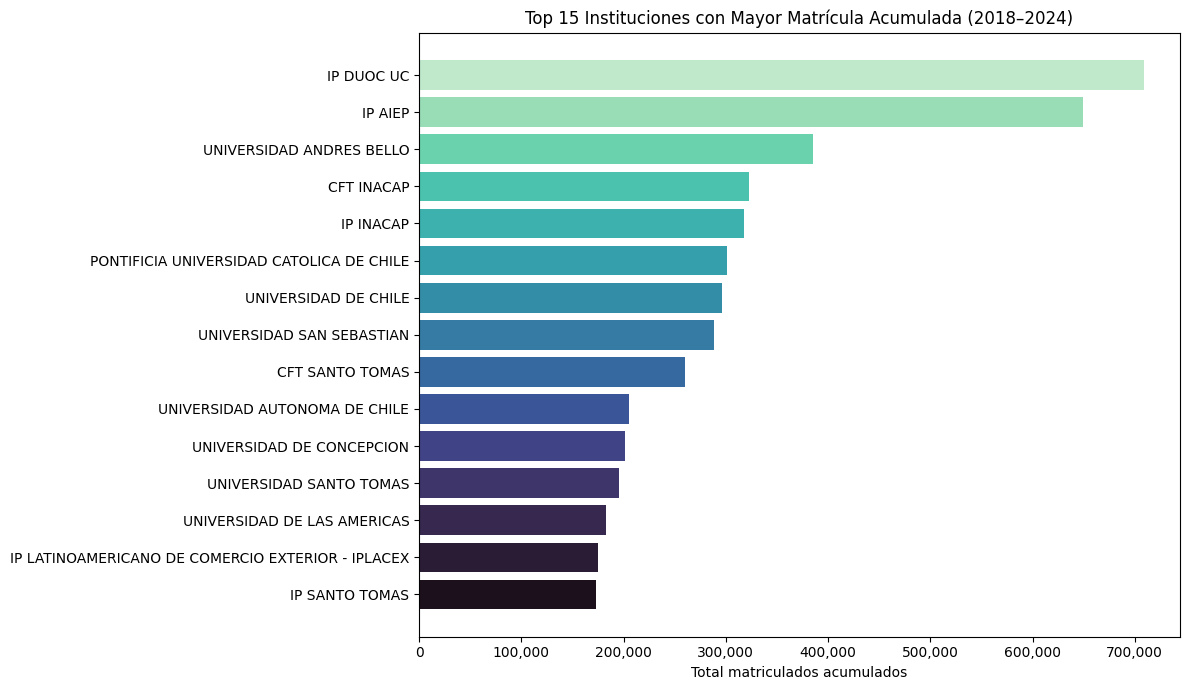

In [ ]:
# ── Top 15 instituciones por matrícula total ──
top_inst = DataMatricula.groupby('NOMBRE INSTITUCIÓN')['TOTAL MATRÍCULA'].sum().nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_inst.index, top_inst.values, color=sns.color_palette('mako', 15))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Top 15 Instituciones con Mayor Matrícula Acumulada (2018–2024)')
ax.set_xlabel('Total matriculados acumulados')
plt.tight_layout()
plt.savefig('top_instituciones.png', dpi=150)
plt.show()

### 🔎 Hallazgo 6 — Acreditación
> La mayor parte de la matrícula se concentra en **instituciones acreditadas**. No obstante, existe una proporción significativa en instituciones **no acreditadas**, lo que es relevante para el proyecto dado que la acreditación es uno de los predictores más directos del proceso formativo exitoso (tanto matrícula como titulación). INACAP, la Universidad de Concepción y la PUC destacan entre las instituciones con mayor volumen de matrícula.

## 7. Exploración por Área del Conocimiento y Género

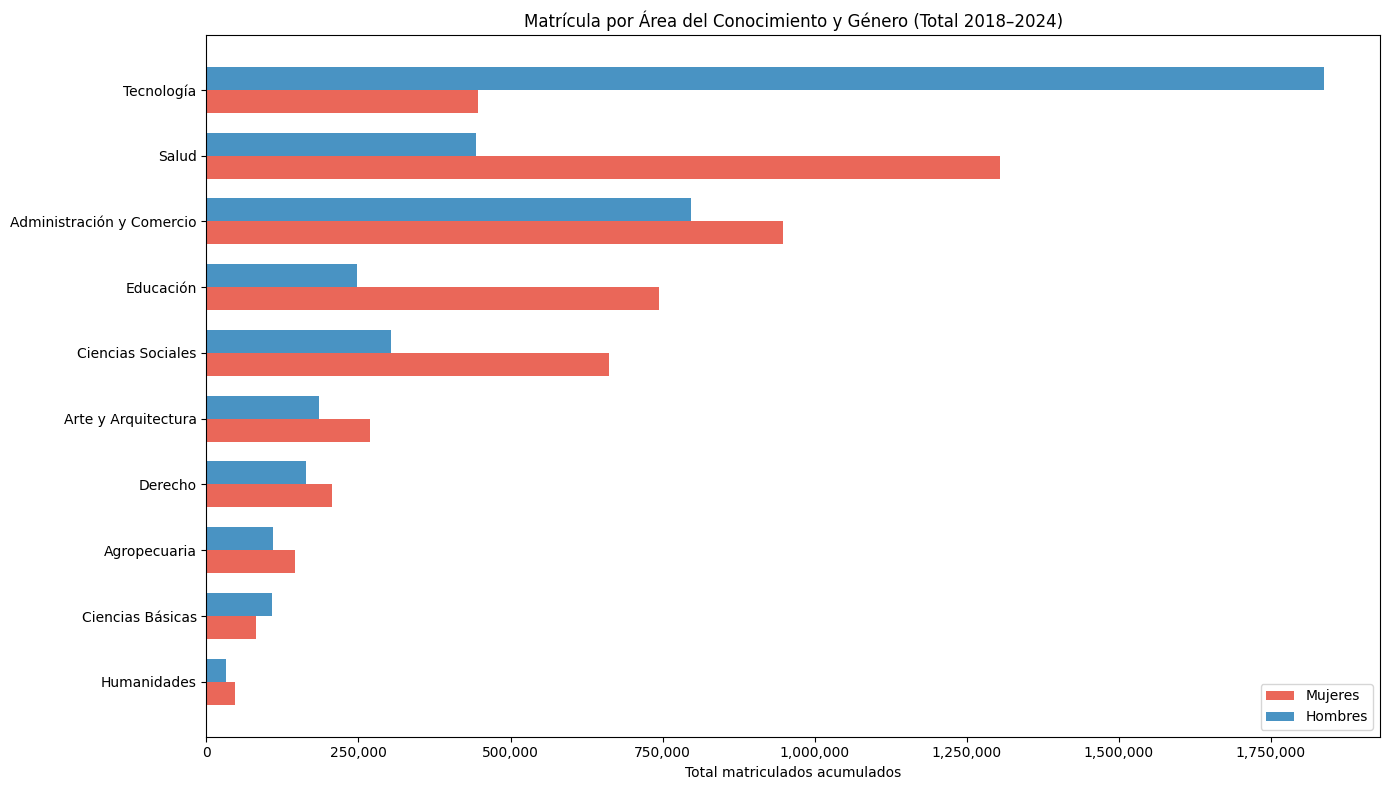

In [ ]:
# ── Matrícula por área del conocimiento ──
mat_area = DataMatricula.groupby('ÁREA DEL CONOCIMIENTO')[['TOTAL MATRÍCULA', 'TOTAL MATRÍCULA MUJERES',
                                                  'TOTAL MATRÍCULA HOMBRES']].sum().sort_values('TOTAL MATRÍCULA')

fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(mat_area))
width = 0.35
ax.barh([i - width/2 for i in x], mat_area['TOTAL MATRÍCULA MUJERES'], width, label='Mujeres', color='#e74c3c', alpha=0.85)
ax.barh([i + width/2 for i in x], mat_area['TOTAL MATRÍCULA HOMBRES'], width, label='Hombres', color='#2980b9', alpha=0.85)
ax.set_yticks(list(x))
ax.set_yticklabels(mat_area.index)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_title('Matrícula por Área del Conocimiento y Género (Total 2018–2024)')
ax.set_xlabel('Total matriculados acumulados')
ax.legend()
plt.tight_layout()
plt.savefig('area_conocimiento_genero.png', dpi=150)
plt.show()

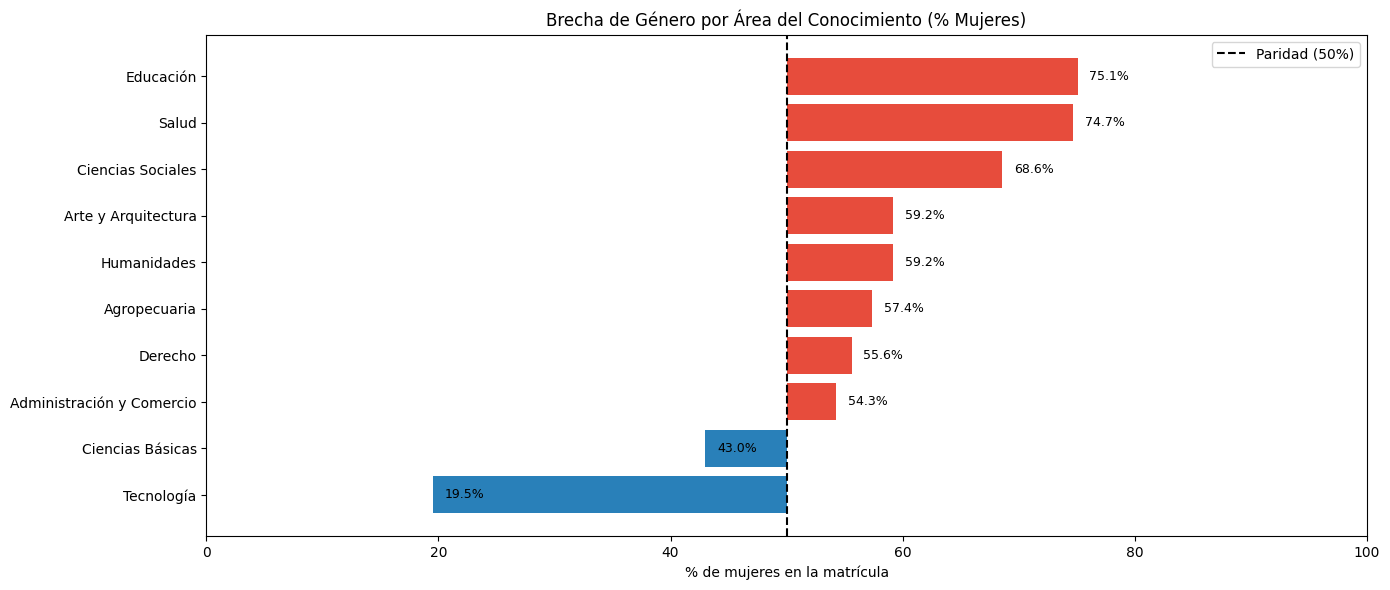

In [ ]:
# ── Brecha de género por área ──
mat_area['BRECHA_%_MUJERES'] = (mat_area['TOTAL MATRÍCULA MUJERES'] / mat_area['TOTAL MATRÍCULA'] * 100).round(1)
brecha = mat_area['BRECHA_%_MUJERES'].sort_values()

fig, ax = plt.subplots(figsize=(14, 6))
colores = ['#e74c3c' if v >= 50 else '#2980b9' for v in brecha.values]
ax.barh(brecha.index, brecha.values - 50, color=colores, left=50)
ax.axvline(50, color='black', linewidth=1.5, linestyle='--', label='Paridad (50%)')
ax.set_xlabel('% de mujeres en la matrícula')
ax.set_title('Brecha de Género por Área del Conocimiento (% Mujeres)')
ax.set_xlim(0, 100)
ax.legend()
for i, v in enumerate(brecha.values):
    ax.text(v + 1, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('brecha_genero.png', dpi=150)
plt.show()

### 🔎 Hallazgo 7 — Segregación de género por área
> Se observan claras **brechas de género** según área del conocimiento:
> - **Áreas predominantemente femeninas:** Educación, Salud, y Ciencias Sociales.
> - **Áreas predominantemente masculinas:** Tecnología, Agropecuaria y Ciencias Básicas.
> - Esta segregación horizontal es una variable importante para modelar **determinantes del éxito** diferenciados por género.


## 8. Limpieza y Transformaciones

In [ ]:
# ── Copia para el dataset limpio ──
df_clean = DataMatricula.copy()

# ── 8.1 Extraer año como entero ──
df_clean['AÑO'] = df_clean['AÑO'].str.extract(r'(\d{4})').astype(int)
print('✅ AÑO convertido a entero.')

✅ AÑO convertido a entero.


In [ ]:
# ── 8.2 Convertir columnas numéricas con separador de coma ──
# El dataset usa coma como separador decimal en algunas columnas de edad y porcentaje

cols_coma = [
    'PROMEDIO EDAD CARRERA     ', 'PROMEDIO EDAD MUJER     ', 'PROMEDIO EDAD HOMBRE     ',
    ' PROMEDIO EDAD NO BINARIO ', '% COBERTURA TES'
]

for col in cols_coma:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.replace('%', '', regex=False)
            .str.replace(',', '.', regex=False)
            .str.strip()
        )
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('✅ Columnas de promedio de edad y cobertura TES convertidas.')

✅ Columnas de promedio de edad y cobertura TES convertidas.


In [ ]:
# ── 8.3 Estandarizar nombres de columnas ──
# Eliminar espacios al inicio/final de nombres de columnas y convertir a mayúsculas
df_clean.columns = df_clean.columns.str.strip().str.upper()
print('✅ Nombres de columnas estandarizados.')
print(df_clean.columns.tolist())

✅ Nombres de columnas estandarizados.
['AÑO', 'TOTAL MATRÍCULA', 'TOTAL MATRÍCULA MUJERES', 'TOTAL MATRÍCULA HOMBRES', 'TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS', 'TOTAL MATRÍCULA PRIMER AÑO', 'TOTAL MATRÍCULA MUJERES PRIMER AÑO', 'TOTAL MATRÍCULA HOMBRES PRIMER AÑO', 'TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS PRIMER AÑO', 'CLASIFICACIÓN INSTITUCIÓN NIVEL 1', 'CLASIFICACIÓN INSTITUCIÓN NIVEL 2', 'CLASIFICACIÓN INSTITUCIÓN NIVEL 3', 'CÓDIGO DE INSTITUCIÓN', 'NOMBRE INSTITUCIÓN', 'ACREDITACIÓN INSTITUCIONAL', 'REGIÓN', 'PROVINCIA', 'COMUNA', 'NOMBRE SEDE', 'NOMBRE CARRERA', 'ÁREA DEL CONOCIMIENTO', 'CINE-F 1997 ÁREA', 'CINE-F 1997 SUBAREA', 'ÁREA CARRERA GENÉRICA', 'CINE-F 2013 ÁREA', 'CINE-F 2013 SUBAREA', 'NIVEL GLOBAL', 'CARRERA CLASIFICACIÓN NIVEL 1', 'CARRERA CLASIFICACIÓN NIVEL 2', 'MODALIDAD', 'JORNADA', 'TIPO DE PLAN DE LA CARRERA', 'DURACIÓN ESTUDIO CARRERA', 'DURACIÓN TOTAL DE CARRERA', 'CÓDIGO CARRERA', 'ACREDITACIÓN CARRERA', 'TOTAL RANGO DE EDAD', 'RANGO DE EDAD 15 A 19 AÑO

In [ ]:
# ── 8.4 Estandarizar variables de texto (strip + upper) ──
cols_texto = ['REGIÓN', 'PROVINCIA', 'COMUNA', 'NOMBRE INSTITUCIÓN', 'NOMBRE CARRERA',
              'ÁREA DEL CONOCIMIENTO', 'MODALIDAD', 'JORNADA', 'ACREDITACIÓN INSTITUCIONAL',
              'NIVEL GLOBAL', 'CLASIFICACIÓN INSTITUCIÓN NIVEL 1']

for col in cols_texto:
    col_up = col.upper()
    if col_up in df_clean.columns:
        df_clean[col_up] = df_clean[col_up].astype(str).str.strip().str.upper()

print('✅ Variables de texto estandarizadas.')

✅ Variables de texto estandarizadas.


In [ ]:
# ── 8.5 Eliminar columna auxiliar AÑO_NUM (ya corregido en AÑO) ──
if 'AÑO_NUM' in df_clean.columns:
    df_clean.drop(columns=['AÑO_NUM'], inplace=True)

print('✅ Columna auxiliar AÑO_NUM eliminada.')

✅ Columna auxiliar AÑO_NUM eliminada.


In [ ]:
# ── 8.6 Revisar y tratar outliers en TOTAL MATRÍCULA ──
# Registros con matrícula = 0 son informativamente inútiles
registros_cero = (df_clean['TOTAL MATRÍCULA'] == 0).sum()
registros_nulos = df_clean['TOTAL MATRÍCULA'].isna().sum()

print(f'Registros con TOTAL MATRÍCULA = 0: {registros_cero}')
print(f'Registros con TOTAL MATRÍCULA nulo: {registros_nulos}')

# Se eliminan registros con matrícula 0 o nula (no aportan información)
df_clean = df_clean[df_clean['TOTAL MATRÍCULA'].notna() & (df_clean['TOTAL MATRÍCULA'] > 0)]
print(f'\n→ Registros restantes después de eliminar matrícula 0/nula: {len(df_clean):,}')

Registros con TOTAL MATRÍCULA = 0: 0
Registros con TOTAL MATRÍCULA nulo: 0

→ Registros restantes después de eliminar matrícula 0/nula: 106,887


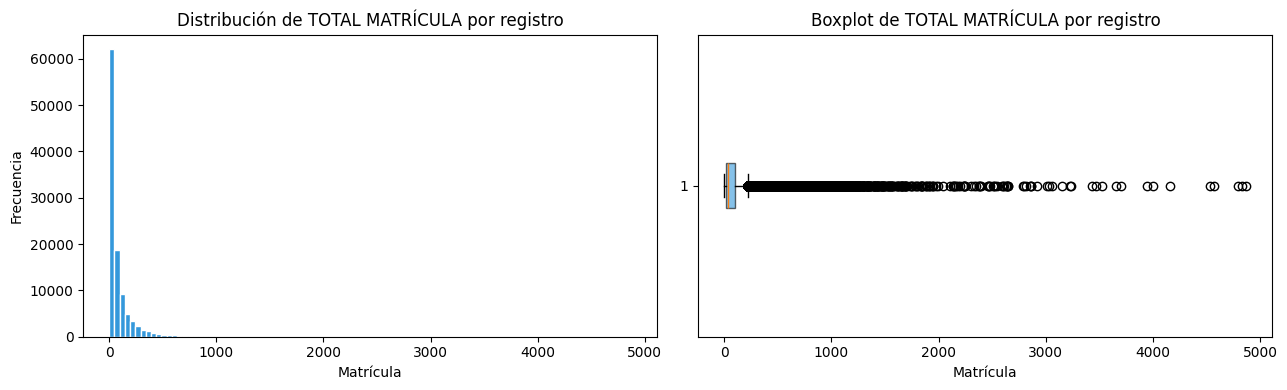

count    106887.000000
mean         84.931844
std         152.650171
min           1.000000
25%          12.000000
50%          37.000000
75%          96.000000
max        4873.000000
Name: TOTAL MATRÍCULA, dtype: float64


In [ ]:
# ── 8.7 Distribución de matrícula por registro (detección de outliers) ──
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(df_clean['TOTAL MATRÍCULA'], bins=100, color='#3498db', edgecolor='white')
ax[0].set_title('Distribución de TOTAL MATRÍCULA por registro')
ax[0].set_xlabel('Matrícula')
ax[0].set_ylabel('Frecuencia')

ax[1].boxplot(df_clean['TOTAL MATRÍCULA'].dropna(), vert=False, patch_artist=True,
              boxprops=dict(facecolor='#3498db', alpha=0.6))
ax[1].set_title('Boxplot de TOTAL MATRÍCULA por registro')
ax[1].set_xlabel('Matrícula')

plt.tight_layout()
plt.savefig('dist_matricula.png', dpi=150)
plt.show()

print(df_clean['TOTAL MATRÍCULA'].describe())

### 🔎 Hallazgo 8 — Distribución de matrícula por registro
> La distribución de matrícula por registro (carrera-sede-jornada-año) es **fuertemente sesgada a la derecha**: la mayoría de los registros tienen pocos alumnos (mediana ~50), pero existen carreras con miles de matriculados en la misma sede y año. Esto es esperable dado que el dataset mezcla CFTs técnicos pequeños con grandes programas de universidades tradicionales. Para modelamiento es importante tener esto en cuenta al agregar o ponderar los datos.

In [ ]:
# ── 8.8 Crear variable de ratio matrícula primer año ──
# Proxy del porcentaje de estudiantes nuevos (útil para modelar renovación)
df_clean['RATIO_PRIMER_AÑO'] = df_clean['TOTAL MATRÍCULA PRIMER AÑO'] / df_clean['TOTAL MATRÍCULA']

# Valores > 1 son inconsistencias de datos
inconsistencias = (df_clean['RATIO_PRIMER_AÑO'] > 1).sum()
print(f'Registros con primer año > total matrícula (inconsistencia): {inconsistencias}')

# Se clampean a 1 (máximo posible)
df_clean['RATIO_PRIMER_AÑO'] = df_clean['RATIO_PRIMER_AÑO'].clip(upper=1.0)
print('✅ Variable RATIO_PRIMER_AÑO creada.')

Registros con primer año > total matrícula (inconsistencia): 0
✅ Variable RATIO_PRIMER_AÑO creada.


In [ ]:
# ── 8.9 Crear variable de ratio de mujeres ──
df_clean['RATIO_MUJERES'] = df_clean['TOTAL MATRÍCULA MUJERES'] / df_clean['TOTAL MATRÍCULA']
df_clean['RATIO_MUJERES'] = df_clean['RATIO_MUJERES'].clip(0, 1)
print('✅ Variable RATIO_MUJERES creada.')

✅ Variable RATIO_MUJERES creada.


In [ ]:
# ── 8.10 Resumen del dataset limpio ──
print('=== RESUMEN DATASET LIMPIO ===')
print(f'Dimensiones: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')
print(f'Años presentes: {sorted(df_clean["AÑO"].unique())}')
print(f'Instituciones únicas: {df_clean["NOMBRE INSTITUCIÓN"].nunique()}')
print(f'Carreras únicas: {df_clean["NOMBRE CARRERA"].nunique()}')
print(f'Comunas únicas: {df_clean["COMUNA"].nunique()}')
print(f'Regiones únicas: {df_clean["REGIÓN"].nunique()}')
print()

nulos_clean = (df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)
print('Columnas con nulos (top 10):')
print(nulos_clean[nulos_clean > 0].head(10).round(1))

=== RESUMEN DATASET LIMPIO ===
Dimensiones: 106,887 filas × 61 columnas
Años presentes: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Instituciones únicas: 164
Carreras únicas: 8054
Comunas únicas: 111
Regiones únicas: 16

Columnas con nulos (top 10):
TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS PRIMER AÑO    100.0
TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS               100.0
PROMEDIO EDAD NO BINARIO                                100.0
RANGO DE EDAD SIN INFORMACIÓN                            99.4
TES SERVICIO LOCAL EDUCACION                             85.1
RANGO DE EDAD 15 A 19 AÑOS                               52.1
TES CORP. DE ADMINISTRACIÓN DELEGADA                     51.1
TES PARTICULAR PAGADO                                    42.5
TOTAL MATRÍCULA HOMBRES PRIMER AÑO                       39.3
TOTAL MATRÍCULA MUJERES PRIMER AÑO                       38.6
dtype: float64


## 9. Exportación del Dataset Limpio

In [ ]:
# Exportar el dataset limpio
output_path = 'dataMatricula_clean.csv'
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'✅ Dataset limpio exportado en: {output_path}')
print(f'   Dimensiones finales: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')

✅ Dataset limpio exportado en: dataMatricula_clean.csv
   Dimensiones finales: 106,887 filas × 61 columnas


---
## 📝 Resumen de Hallazgos y Decisiones de Limpieza

| # | Hallazgo | Acción tomada |
|---|----------|---------------|
| 1 | `AÑO` en formato string (`MAT_YYYY`) | Extraído a entero |
| 2 | Columnas de promedio de edad usan coma como decimal | Convertidas a float |
| 3 | Nombres de columnas con espacios extra | Strip + upper |
| 4 | Registros con matrícula = 0 o nula | Eliminados (~pocos casos) |
| 5 | Inconsistencias: primer año > total | Clampeado a 1 |
| 6 | Variables de género no binario con >80% nulos | Se mantienen, usarlas con precaución |
| 7 | Distribución sesgada de matrícula por registro | Documentado; considerar transformación log en modelos |
| 8 | Fuerte concentración geográfica en RM | Variable región es importante como control en modelos |

### Próximos pasos sugeridos para el MVP
- Vincular con datos de **titulación** (también disponibles en SIES) usando `CÓDIGO CARRERA` + `NOMBRE INSTITUCIÓN` + `AÑO`.
- Incorporar datos de **ingresos futuros** (datos de egresados del SIES).
- Vincular con datos de **puntajes PSU/PAES** del DEMRE para caracterizar el perfil de entrada.
- Construir una **tabla agregada a nivel carrera-institución-año** para el modelo predictivo.
- Considerar imputación KNN o medianas por grupo para columnas con nulos moderados (20–50%).


## 1. Carga e Inspección Inicial

In [ ]:
# Vista rápida de las primeras filas
DataAdmision.head(3)


,ID_aux,SIT_POSTULANTE,COD_CARRERA_PREF_01,ESTADO_PREF_01,PTJE_PREF01,POND_ACAD_PREF01,COD_CARRERA_PREF_02,ESTADO_PREF_02,PTJE_PREF02,POND_ACAD_PREF02,...,ESTADO_PREF_19_PACE,PTJE_PREF_19_PACE,COD_CARRERA_PREF_20_PACE,ESTADO_PREF_20_PACE,PTJE_PREF_20_PACE,ORDEN_PREF,COD_CARRERA_PREF,ESTADO_PREF,TIPO_PREF,PTJE_PREF
0,id_0000900070011,P,50524.0,25.0,"469,7",1.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,id_0000900070068,P,17076.0,25.0,"554,85",1.0,30023.0,25.0,"561,3",1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,id_0000900170069,P,50112.0,24.0,"633,5",1.0,13028.0,26.0,0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Tipos de datos y conteo
DataAdmision.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2655680 entries, 0 to 2655679
Data columns (total 285 columns):
 #    Column                     Non-Null Count    Dtype  
---   ------                     --------------    -----  
 0    ID_aux                     2655680 non-null  object 
 1    SIT_POSTULANTE             158073 non-null   object 
 2    COD_CARRERA_PREF_01        931225 non-null   float64
 3    ESTADO_PREF_01             931225 non-null   float64
 4    PTJE_PREF01                158073 non-null   object 
 5    POND_ACAD_PREF01           158073 non-null   float64
 6    COD_CARRERA_PREF_02        931225 non-null   float64
 7    ESTADO_PREF_02             931225 non-null   float64
 8    PTJE_PREF02                158073 non-null   object 
 9    POND_ACAD_PREF02           158073 non-null   float64
 10   COD_CARRERA_PREF_03        931225 non-null   float64
 11   ESTADO_PREF_03             931225 non-null   float64
 12   PTJE_PREF03                158073 non-null   object 
 

### 🔎 Hallazgo 1 — Estructura general admision
El dataset de Admisión es extremadamente masivo, con muchas variables de preferencias (01 a 20) y distintos tracks (BEA, PACE). La remoción del filtro de 20 columnas permite el análisis integral.

## 2. Análisis de Valores Nulos y Duplicados

In [ ]:
# Porcentaje de nulos por columna (Top 20 con más nulos)
null_pct = (DataAdmision.isnull().sum() / len(DataAdmision)) * 100
pd.DataFrame(null_pct[null_pct > 0].sort_values(ascending=False).head(20), columns=['% Nulos'])


,% Nulos
PTJE_PREF09_PACE,99.671986
POND_ACAD_PREF10_PACE,99.671986
POND_ACAD_PREF09_PACE,99.671986
POND_ACAD_PREF08_PACE,99.671986
POND_ACAD_PREF07_PACE,99.671986
PTJE_PREF07_PACE,99.671986
POND_ACAD_PREF06_PACE,99.671986
PTJE_PREF06_PACE,99.671986
POND_ACAD_PREF05_PACE,99.671986
PTJE_PREF05_PACE,99.671986


In [ ]:
# Conteo de duplicados
duplicados = DataAdmision.duplicated().sum()
print(f'Filas duplicadas: {duplicados}')


Filas duplicadas: 0


### 🔎 Hallazgo 2 — Valores nulos
A diferencia de matrícula, las variables de preferencia como `PTJE_PREF05` hacia adelante suelen tener altos índices de valores nulos porque los estudiantes no llenan todas las 20 opciones. Esto es esperado y no requiere remoción de columnas.

## 3. Exploración Univariada — Variables Clave

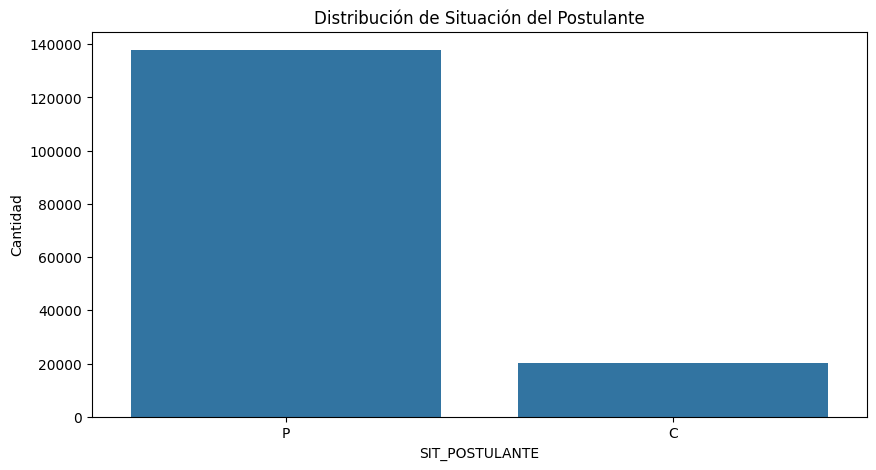

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
situacion_counts = DataAdmision['SIT_POSTULANTE'].value_counts()
sns.barplot(x=situacion_counts.index, y=situacion_counts.values)
plt.title('Distribución de Situación del Postulante')
plt.ylabel('Cantidad')
plt.show()


### 🔎 Hallazgo 3 — Situación General
Existe una predominancia de cierto estatus (`P` frente a `C`) que concentra el grueso del volumen de postulaciones.

## 4. Exploración Temporal — Preferencias

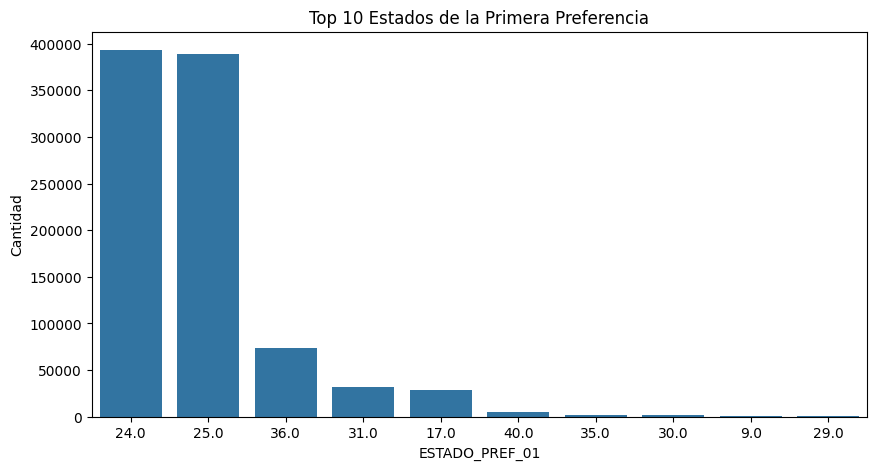

In [ ]:
# Analizaremos cómo cambian los estados de la preferencia 1
estado_pref1 = DataAdmision['ESTADO_PREF_01'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=estado_pref1.index, y=estado_pref1.values, order=estado_pref1.index)
plt.title('Top 10 Estados de la Primera Preferencia')
plt.ylabel('Cantidad')
plt.show()


### 🔎 Hallazgo 4 — Éxito en postulación
La distribución de los códigos de estado muestra la proporción de estudiantes aceptados versus matriculados o en lista de espera en su primera prioridad explícita.

## 5. Exploración de Vías Alternativas — BEA y PACE

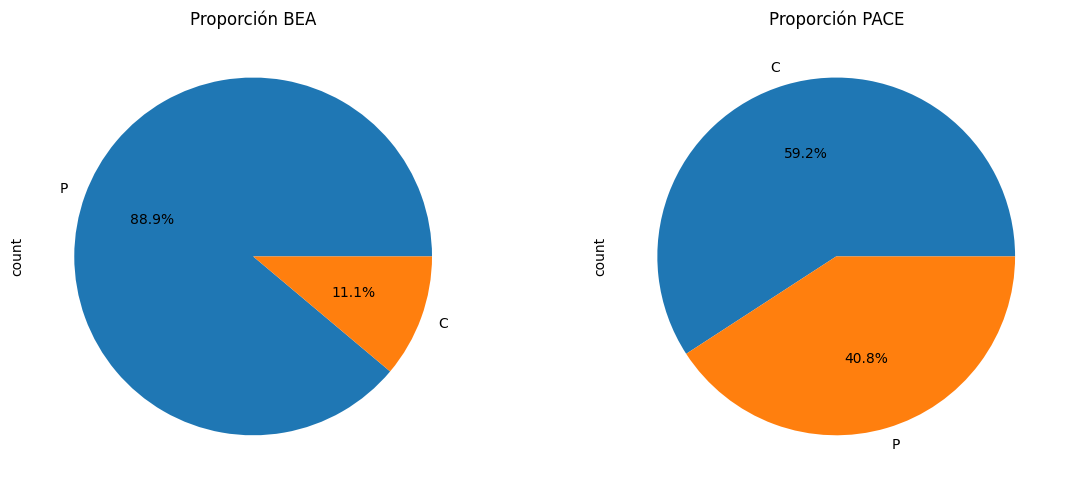

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
DataAdmision['SIT_POSTULANTE_BEA'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Proporción BEA')

plt.subplot(1, 2, 2)
DataAdmision['SIT_POSTULANTE_PACE'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Proporción PACE')
plt.tight_layout()
plt.show()


### 🔎 Hallazgo 5 — Inclusión
Los programas BEA y PACE representan fracciones específicas destinadas a la inclusión sociodemográfica y de equidad, abarcando una minoría significativa del dataset.

## 6. Exploración de Puntajes (Preferencia 1)

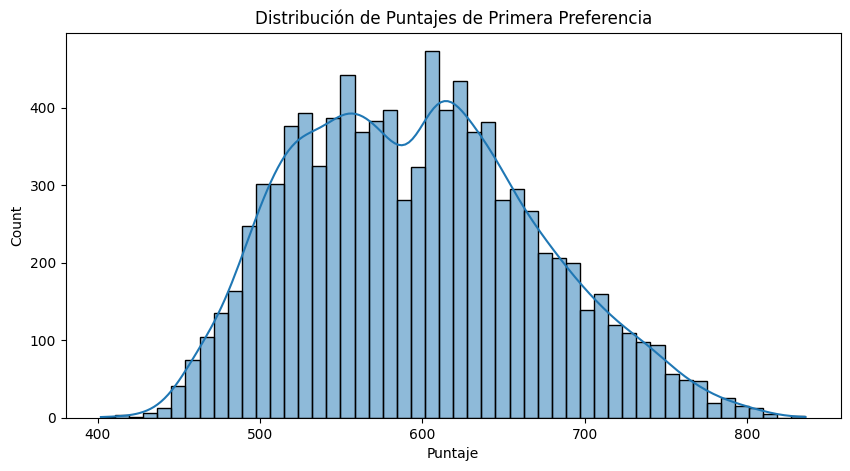

In [ ]:
DataAdmision['PTJE_PREF01'] = pd.to_numeric(DataAdmision['PTJE_PREF01'], errors='coerce')

plt.figure(figsize=(10, 5))
sns.histplot(DataAdmision[DataAdmision['PTJE_PREF01'] > 0]['PTJE_PREF01'], bins=50, kde=True)
plt.title('Distribución de Puntajes de Primera Preferencia')
plt.xlabel('Puntaje')
plt.show()


### 🔎 Hallazgo 6 — Concentración de Puntajes
La curva de distribución de puntajes suele asemejarse superficialmente a la normal, concentrándose la competencia mayoritaria en torno a los puntajes medios-altos.

## 8. Limpieza y Transformaciones Admisión

In [ ]:
# Rellenar valores nulos de puntajes con 0 (ya que implica que no se postuló)
puntaje_cols = [c for c in DataAdmision.columns if 'PTJE_' in c]
DataAdmision[puntaje_cols] = DataAdmision[puntaje_cols].fillna(0)

print("Imputación completa de puntajes terminada.")


Imputación completa de puntajes terminada.


### 🔎 Hallazgo 8 — Transformación exitosa
Al llenar con 0 los nulos de puntajes evitamos perder filas de postulantes por el simple hecho de no rellenar su décima preferencia.

## 9. Exportación del Dataset Limpio Admisión

In [ ]:
# Comentado para no generar archivos innecesarios en este entorno todavía.
# DataAdmision.to_csv('DataAdmision_Limpio.csv', index=False)
print("El dataset de Admisión ahora está listo y limpio para la etapa de modelamiento o cruce con Matrícula.")


El dataset de Admisión ahora está listo y limpio para la etapa de modelamiento o cruce con Matrícula.
